In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly_express as px


In [3]:
df = pd.read_csv('data/financial_data.csv', index_col=0)
df

,btc_close,btc_volume,gld_price,gld_volume,uso_price,uso_volume,treasury_3m_yield,sp500_price,sp500_volume
2015-07-20,280.00,782.883420,105.699997,15751700.0,133.520004,2055688.0,0.023,2128.280029,3.245870e+09
2015-07-21,277.32,4943.559434,105.370003,10519800.0,135.279999,1602138.0,0.030,2119.209961,3.343690e+09
2015-07-22,277.89,4687.909383,104.800003,8349200.0,130.720001,3386963.0,0.030,2114.149902,3.694070e+09
2015-07-23,277.39,5306.919575,104.330002,5779300.0,129.119995,2836525.0,0.030,2102.149902,3.772810e+09
2015-07-24,289.12,7362.469083,105.349998,11572700.0,128.240005,2905775.0,0.030,2079.649902,3.870040e+09
...,...,...,...,...,...,...,...,...,...
2025-03-18,82698.76,7316.632966,279.959991,9596500.0,72.209999,2739000.0,4.195,5614.660156,4.666270e+09
2025-03-19,86877.96,13053.658037,281.109985,8822200.0,72.419998,1747400.0,4.190,5675.290039,4.660090e+09
2025-03-20,84183.42,9880.316963,280.750000,5863300.0,73.730003,2523100.0,4.182,5662.890137,4.678420e+09
2025-03-21,84061.96,6257.635588,278.489990,8891700.0,73.790001,1528800.0,4.185,5667.560059,9.367460e+09


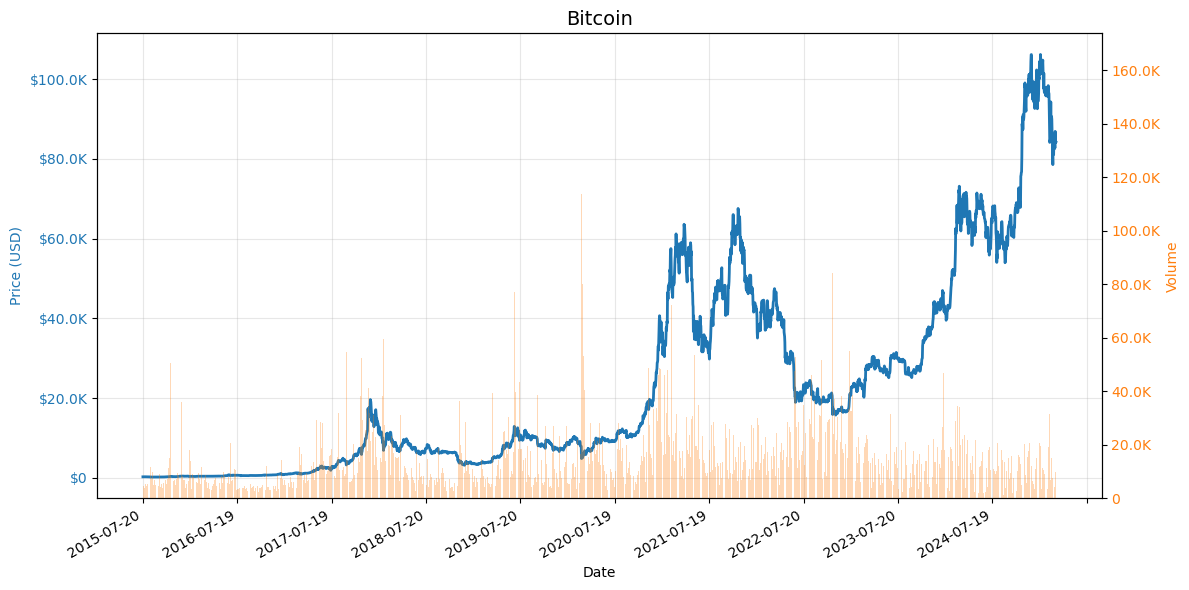

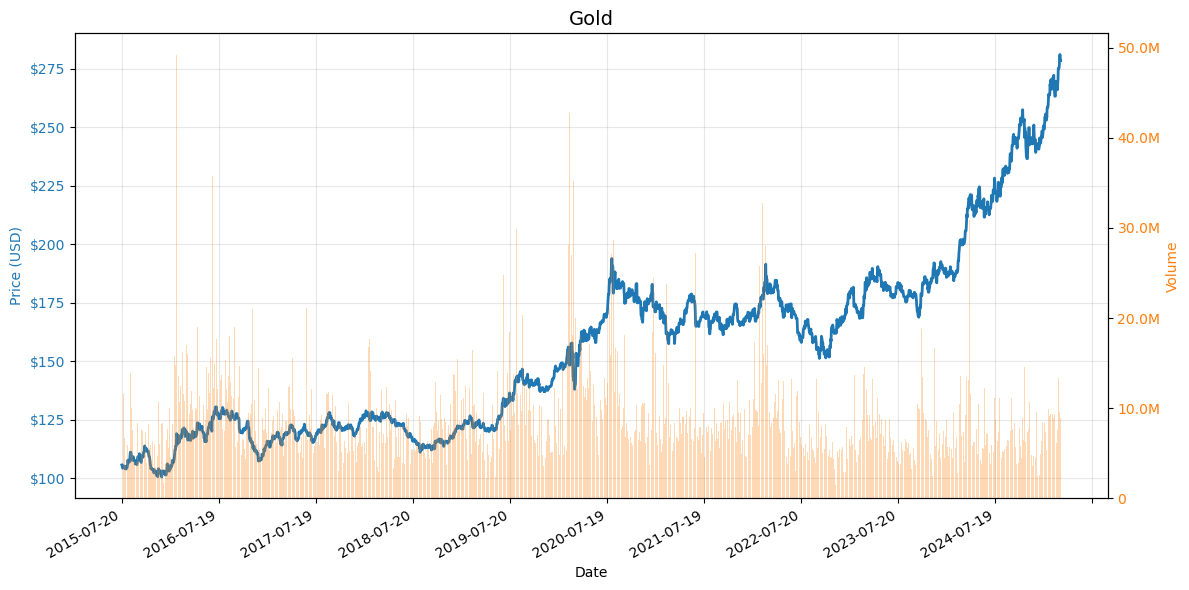

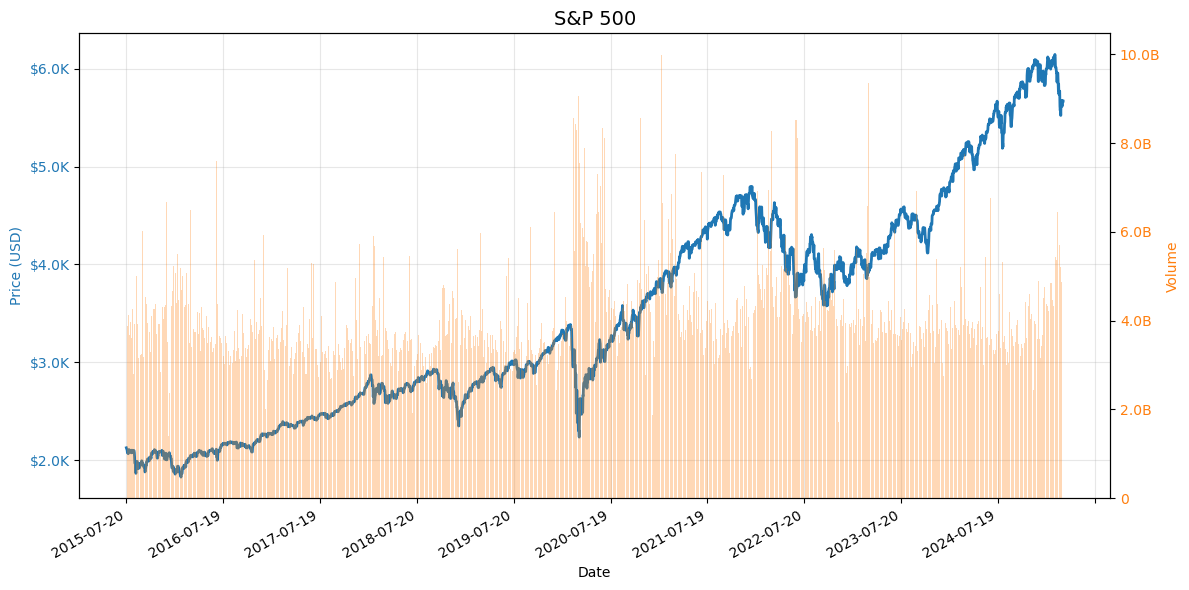

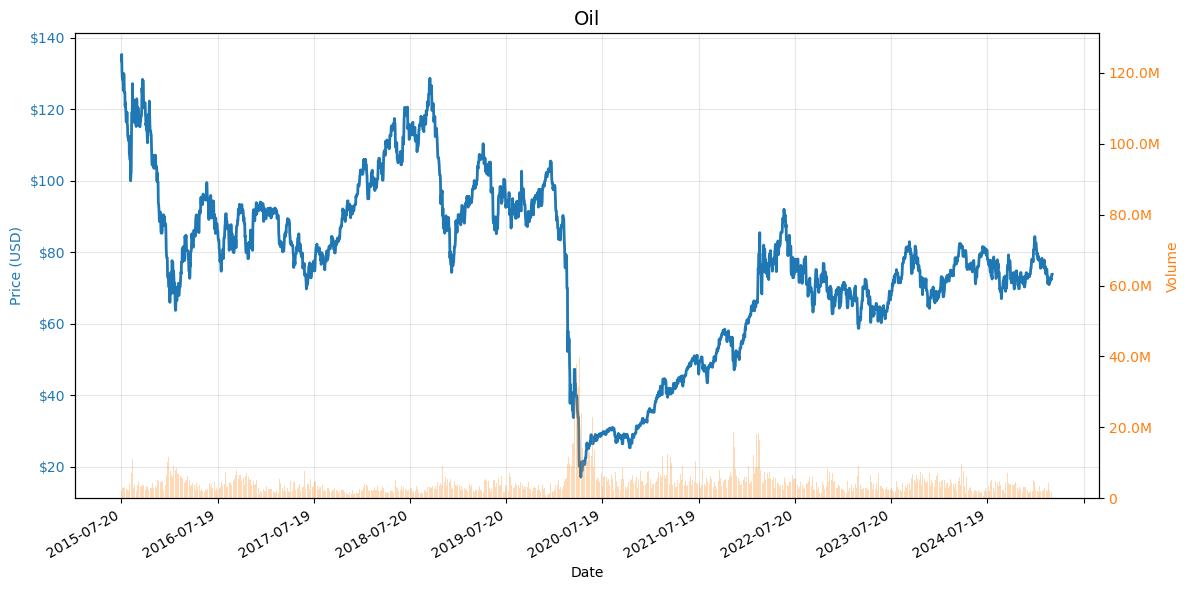

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

def plot_price_volume(df, price_column=0, volume_column=1, 
                      title="Bitcoin Price and Volume", 
                      figsize=(12, 6), 
                      price_color='#1f77b4', 
                      volume_color='#ff7f0e',
                      price_label='Price (USD)',
                      volume_label='Volume'):
    """
    Plot price and volume on a dual-axis chart.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing price and volume data
    date_column : str or None
        Column name for dates. If None, assumes df index is the date
    price_column : str or int
        Column name or index for price data
    volume_column : str or int
        Column name or index for volume data
    title : str
        Chart title
    figsize : tuple
        Figure size as (width, height)
    price_color : str
        Color for price line
    volume_color : str
        Color for volume bars
    price_label : str
        Label for price axis
    volume_label : str
        Label for volume axis
    
    Returns:
    --------
    fig, ax1, ax2 : matplotlib figure and axes objects
    """
    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Get x-axis dates
    x = df.index
    
    # Get price and volume data
    if isinstance(price_column, int):
        price = df.iloc[:, price_column]
    else:
        price = df[price_column]
        
    if isinstance(volume_column, int):
        volume = df.iloc[:, volume_column]
    else:
        volume = df[volume_column]
    
    # Plot price on primary axis
    ax1.plot(x, price, color=price_color, linewidth=2)
    ax1.set_xlabel('Date')
    ax1.set_ylabel(price_label, color=price_color)
    ax1.tick_params(axis='y', labelcolor=price_color)
    
    # Format y-axis for price
    def price_formatter(x, pos):
        if x >= 1000:
            return f'${x/1000:.1f}K'
        else:
            return f'${x:.0f}'
    
    ax1.yaxis.set_major_formatter(FuncFormatter(price_formatter))
    
    # Create secondary axis for volume
    ax2 = ax1.twinx()
    
    # Plot volume on secondary axis
    ax2.bar(x, volume, color=volume_color, alpha=0.3, width=0.8)
    ax2.set_ylabel(volume_label, color=volume_color)
    ax2.tick_params(axis='y', labelcolor=volume_color)
    
    # Format y-axis for volume
    def volume_formatter(x, pos):
        if x >= 1e9:
            return f'{x/1e9:.1f}B'
        elif x >= 1e6:
            return f'{x/1e6:.1f}M'
        elif x >= 1e3:
            return f'{x/1e3:.1f}K'
        else:
            return f'{x:.0f}'
    
    ax2.yaxis.set_major_formatter(FuncFormatter(volume_formatter))
            
    # ax1.xaxis.set_major_formatter(mdates.DateFormatter('%YY'))
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    
    # Add title and grid
    plt.title(title, fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Ensure dates are readable
    fig.autofmt_xdate()
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax1, ax2

btc=df[['btc_close', 'btc_volume']]
plot_price_volume(btc, price_column=0, volume_column=1, title='Bitcoin')
plt.show()
gold = df[['gld_price', 'gld_volume']]
plot_price_volume(gold, price_column=0, volume_column=1, title='Gold')
plt.show()
sp500 = df[['sp500_price', 'sp500_volume']]
plot_price_volume(sp500, price_column=0, volume_column=1, title='S&P 500')
plt.show()
uso = df[['uso_price', 'uso_volume']]
plot_price_volume(uso, price_column=0, volume_column=1, title='Oil')
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
px.line(df_scaled).show()

<Axes: >

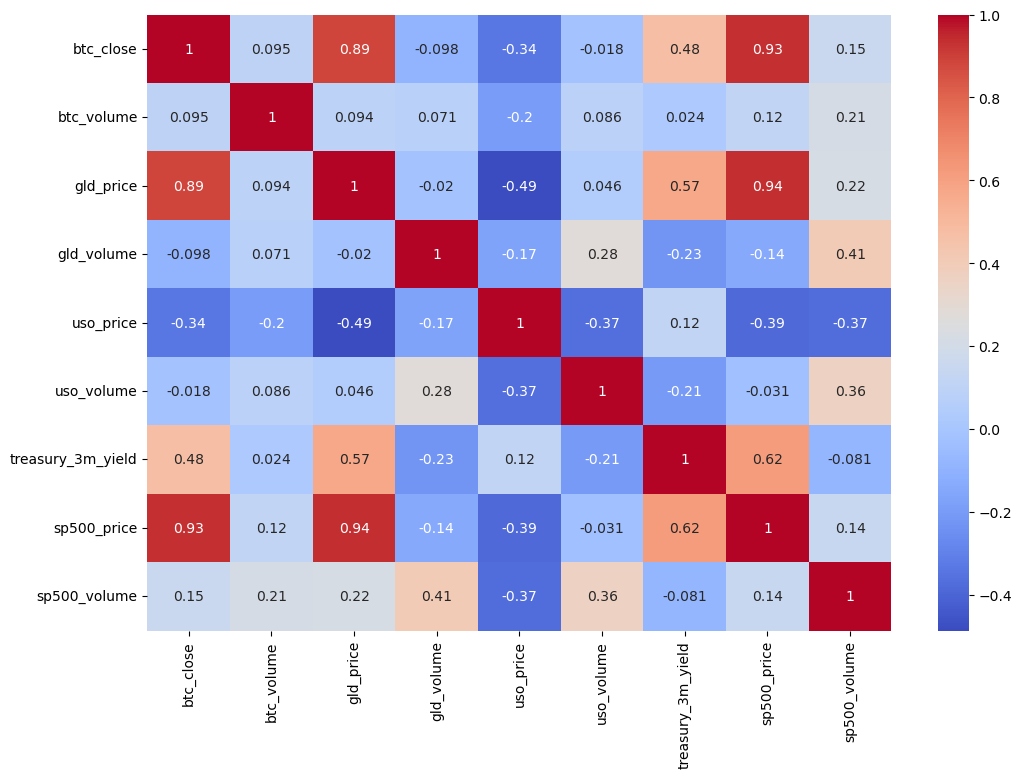

In [9]:
# increase size of figure
plt.figure(figsize=(12, 8))
# plot heatmap
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm')